# Mesh

The mesh stage turns the depth maps and cameras from the reconstruction into a surface: it fuses
the depth into a voxel grid, extracts a triangle mesh, cleans it, and paints the keyframes onto
it as a texture. This page runs each step by hand, then shows the textured mesh the stage wrote.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import open3d as o3d
import pyvista as pv

from collab_splats.geometry.transforms import invert_poses
from collab_splats.mesh import (
    clean_repair_mesh,
    compute_tsdf_voxel_size,
    create_tsdf_mesh,
    prepare_mesh,
)
from collab_splats.pointcloud import PointcloudResult
from collab_splats.pointcloud.utils import frame_depths
from collab_splats.preproc import frames
from collab_splats.semantics import sky_masks
from collab_splats.utils.visualization import apply_view, camera_view

%run ../tutorial.py

scene = tutorial_scene("preproc", "pointcloud", "mesh")

[Open3D WARNING] Write Ply clamped color value to valid range


## 1. Fusing depth into a surface

Each voxel stores its distance to the nearest surface, averaged over every view that sees it
(a TSDF). The mesh is drawn where that distance is zero. Two numbers matter: `voxel_size` is the
grid resolution, and `sdf_trunc` is how far from a surface each view writes. Structures thinner
than `sdf_trunc` do not survive.

Load the depth maps, cameras and frames; low-confidence depth is dropped:

In [2]:
cfg = scene.config["mesh"]
out_dir = work_dir("mesh")

pointcloud = PointcloudResult.load_zarr(
    scene.pointcloud_zarr, load_images=False, load_world_points=False
)
image_ids = [frames.frame_idx_from_path(p) for p in pointcloud.image_paths]
rgbs = frames.read_frames(scene.images_dir, image_ids)
depths = frame_depths(pointcloud, rgbs, conf_percentile=cfg["conf_percentile"])
c2w = invert_poses(pointcloud.extrinsics)

valid = np.count_nonzero(depths) / depths.size
print(f"{len(depths)} depth maps, {valid:.1%} of pixels kept")

96 depth maps, 80.0% of pixels kept


Sky has no real depth; fused, it becomes a far backdrop and stray blobs. A sky segmenter finds
it in every frame and its depth is removed. The farthest 5% of depth goes too, so a few distant
pixels cannot stretch the grid.

sky: 23.7% of all pixels


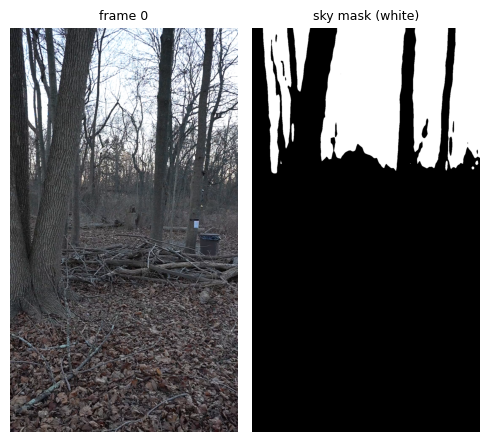

In [3]:
sky = sky_masks(scene.images_dir, idxs=image_ids, cache_dir=out_dir / "sky")
depths = np.where(sky, 0.0, depths)

# Cut far depth before sizing the voxels, as the stage does
sub = depths[:, ::8, ::8]
depth_trunc = float(np.percentile(sub[sub > 0], cfg["depth_trunc_percentile"]))
depths = np.where(depths > depth_trunc, 0.0, depths)

fig, axes = plt.subplots(1, 2, figsize=(5, 4.5))
axes[0].imshow(rgbs[0])
axes[0].set_title(f"frame {image_ids[0]}", fontsize=9)
axes[1].imshow(sky[0], cmap="gray")
axes[1].set_title("sky mask (white)", fontsize=9)

for ax in axes:
    ax.axis("off")

plt.tight_layout()
print(f"sky: {sky.mean():.1%} of all pixels")

White pixels are what the segmenter called sky; their depth is not fused.

Pick the voxel size from the scene's own depth, then fuse:

In [4]:
voxel_size = compute_tsdf_voxel_size(
    depths,
    c2w,
    pointcloud.intrinsics,
    depth_fx=float(np.median(pointcloud.model_intrinsics[:, 0, 0])),
    depth_px=cfg["voxel_depth_px"],
    ref_percentile=cfg["voxel_ref_percentile"],
)
sdf_trunc = cfg["sdf_trunc_mult"] * voxel_size
fused = create_tsdf_mesh(
    depths, rgbs, c2w, pointcloud.intrinsics, voxel_size=voxel_size, sdf_trunc=sdf_trunc
)
print(f"voxel {voxel_size:.4f}, sdf_trunc {sdf_trunc:.4f}, {len(fused.triangles):,} triangles")

voxel 0.0024, sdf_trunc 0.0094, 2,633,986 triangles


## 2. Cleaning

`clean_repair_mesh` removes floating fragments, fills holes and, for outdoor scenes, trims the
ragged rim and closes the ground. `prepare_mesh` then reduces the triangle count and smooths the
surface; its output is what the stage saves as `mesh.ply`. The surface right after the floater
cut (`real`) is kept for the texture step.

In [5]:
# Clean a copy so the fused mesh stays for comparison
cleaned, real = clean_repair_mesh(
    o3d.geometry.TriangleMesh(fused), use_convex_hull=cfg["use_convex_hull"]
)
prepared = prepare_mesh(
    cleaned,
    voxel_size=voxel_size,
    smooth_iterations=cfg["smooth_iterations"],
    max_faces=cfg["max_faces"],
)
print(f"fused {len(fused.triangles):,} -> prepared {len(prepared.triangles):,} triangles")

fused 2,633,986 -> prepared 683,330 triangles


Fused (left) and cleaned (right), seen from the side:

[Open3D WARNING] Write Ply clamped color value to valid range


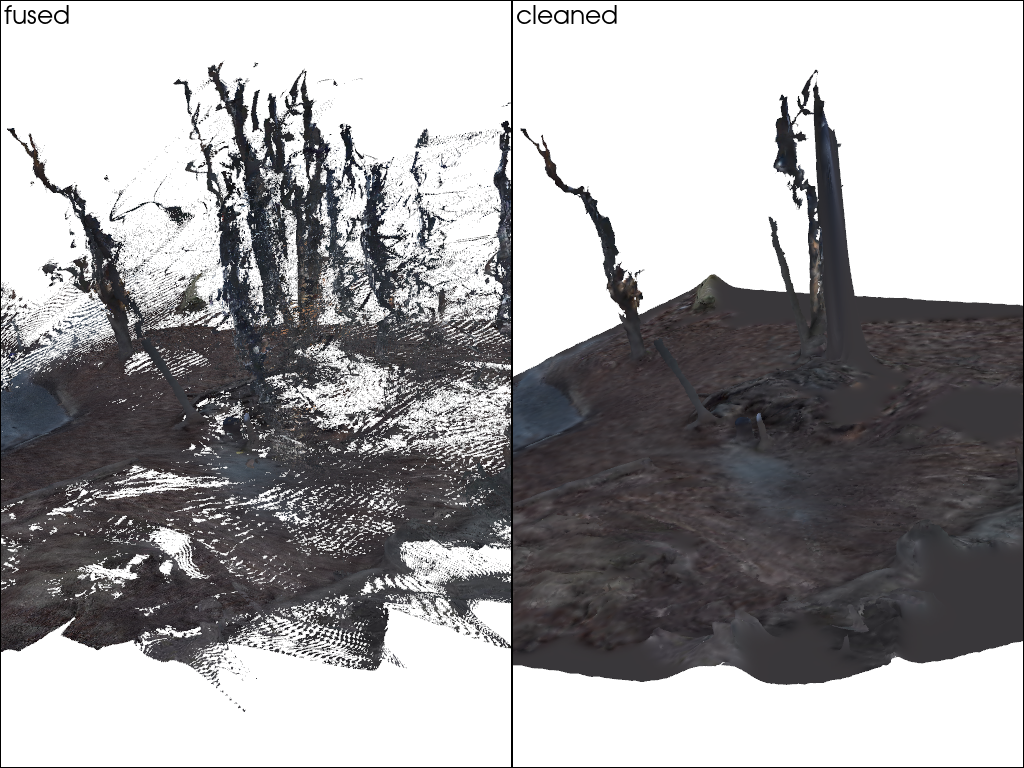

In [6]:
fused_path = out_dir / "fused.ply"
prepared_path = out_dir / "prepared.ply"
o3d.io.write_triangle_mesh(str(fused_path), fused)
o3d.io.write_triangle_mesh(str(prepared_path), prepared)

pl = pv.Plotter(shape=(1, 2))

for col, (title, path) in enumerate([("fused", fused_path), ("cleaned", prepared_path)]):
    pl.subplot(0, col)
    pl.add_text(title, font_size=10)
    pl.add_mesh(pv.read(str(path)), rgb=True, lighting=False)

pl.link_views()
apply_view(pl, camera_view(pointcloud.extrinsics, np.asarray(prepared.vertices)))
pl.show()

The fused mesh has floating specks and a ragged rim; the cleaned one should have neither.

## 3. Texture

Vertex colors are only as sharp as the vertices are dense. A texture stores color in an image
instead: each part of the mesh gets its color from the sharpest keyframes that see it. The stage
does this with `mesh.texture: true` (CUDA only) and writes `texture/mesh.obj` and its image.

The stage's mesh up close, with vertex colors and with the texture:

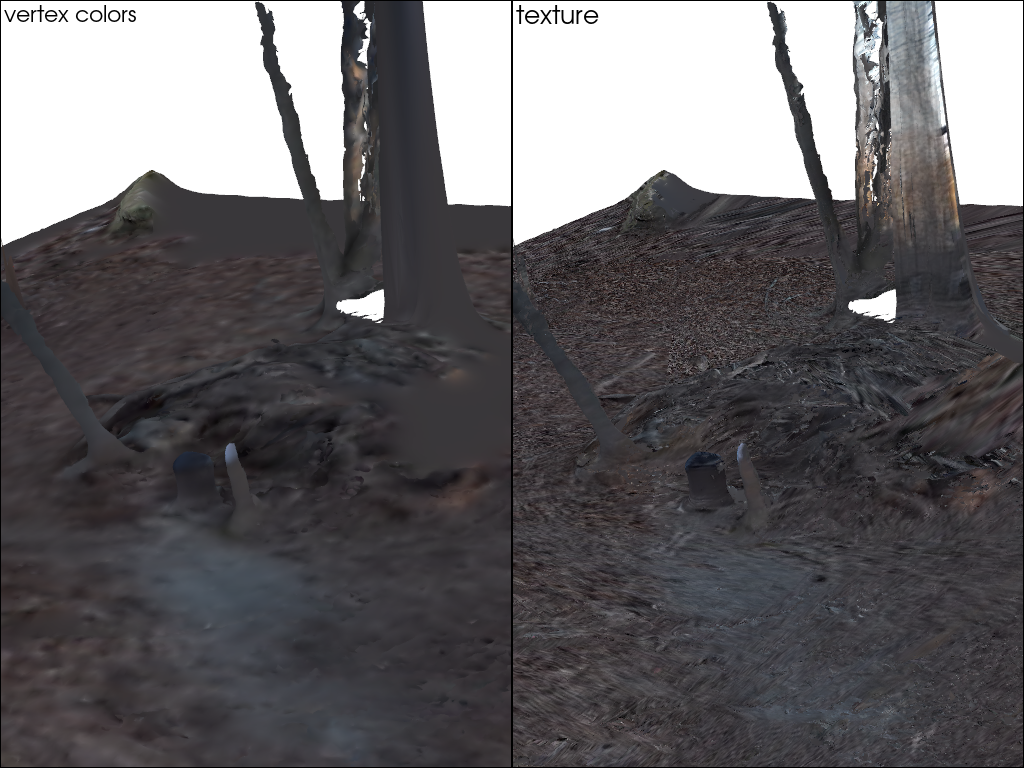

In [7]:
texture_dir = scene.backend_dir / "texture"
vertex_colored = pv.read(str(scene.outputs["mesh"]))
textured = pv.read(str(texture_dir / "mesh.obj"))
albedo = pv.read_texture(str(texture_dir / "albedo.png"))

pl = pv.Plotter(shape=(1, 2))
pl.subplot(0, 0)
pl.add_text("vertex colors", font_size=10)
pl.add_mesh(vertex_colored, rgb=True, lighting=False)
pl.subplot(0, 1)
pl.add_text("texture", font_size=10)
pl.add_mesh(textured, texture=albedo, lighting=False)
pl.link_views()
apply_view(pl, camera_view(pointcloud.extrinsics, vertex_colored.points, distance=0.6))
pl.show()

Same mesh in both panels; the texture keeps the detail between vertices.

## In a pipeline run

The `mesh` stage runs all three sections and writes `mesh.ply`, plus `texture/` when `texture`
is on. The `configs/base.yaml` defaults, which this scene uses:

```yaml
mesh:
  source: feedforward       # pointcloud.zarr depth
  depth_trunc_percentile: 95  # drop depth beyond this percentile
  voxel_depth_px: 4.0       # voxel edge in depth-pixel footprints
  voxel_ref_percentile: 50  # depth percentile the footprint is measured at
  sdf_trunc_mult: 4.0       # sdf_trunc = sdf_trunc_mult x voxel_size
  conf_percentile: 20
  mask_sky: true            # remove sky depth before fusion
  max_faces: 1500000        # face budget for mesh.ply
  smooth_iterations: 10
  texture: true             # texture image into texture/; CUDA only
  use_convex_hull: true
```